# MCYSD-23 Machine Learning Optimization Lecture

A Jupyter notebook demonstrating concepts of machine learning optimization.
It covers GD, AdaGrad, RMSProp, Adam, Momentum, and compares some concepts to sklearn.
It discusses learning rate and hyperparameter tuning, and provides visualizations for comparisons and understanding of convergence and behaviours.

Group Members
- John P.
- Alvaro G. G.
- Chris D.

In [42]:
## Imports
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import inspect
from math import sqrt
from ipywidgets import interact, fixed

### Introduction: Function and Slope from Derivative

We have a function and want to get to the lowest point to minimize it.
This represents our loss function which we want to minimize.

We can use the derivative to find the slope of the function at any point.
Naively, we can take a step down the slope to get closer to the minimum.
This is our gradient, which we use to descend the function.

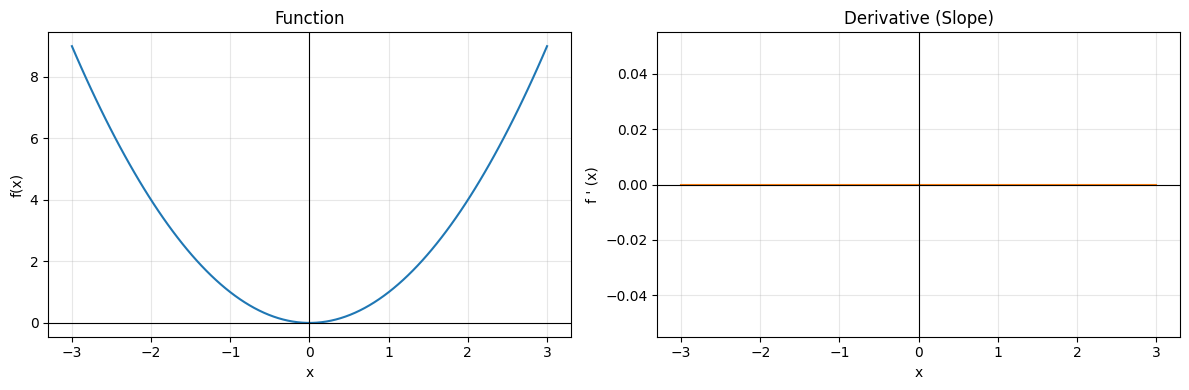

In [47]:
# This is our function
# It represents our loss function
# We want to minimize this
def f(x):
    return x**2

# Our derivative can tell us which direction "down" is
def df(x):
    return x*0 #TODO: Calculate the derivative

# Domain
x = np.linspace(-3, 3, 100)

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, f(x), color="tab:blue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Function")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, df(x), color="tab:orange")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Derivative (Slope)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f ' (x)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interactive function

In [37]:
def interactive_optimizer_plot(
    optimizer,
    gradient,
    loss_function,
    x_range=(-3, 3),
    zoom_on_points=True,
    zoom_margin=0.5,
    num_points=400,
    default_params=None,
    slider_config=None,
    title=None
):

    if default_params is None:
        default_params = {}

    if slider_config is None:
        slider_config = {}

    sig = inspect.signature(optimizer)
    params = sig.parameters

    candidate_controls = [
        "learning_rate",
        "num_iterations",
        "x_start",
        "beta",
        "beta1",
        "beta2",
    ]

    default_slider_settings = {
        "learning_rate": {"min": 0.001, "max": 2.0, "step": 0.001},
        "num_iterations": {"min": 1, "max": 100, "step": 1},
        "x_start": {"min": x_range[0], "max": x_range[1], "step": 0.1},
        "beta": {"min": 0.0, "max": 0.999, "step": 0.01},
        "beta1": {"min": 0.0, "max": 0.999, "step": 0.01},
        "beta2": {"min": 0.0, "max": 0.999, "step": 0.01},
    }

    controls = {}

    for name in candidate_controls:
        if name not in params:
            continue

        param = params[name]

        if name in default_params:
            value = default_params[name]
        elif param.default is not inspect._empty:
            value = param.default
        else:
            fallback = {
                "learning_rate": 0.1,
                "num_iterations": 30,
                "x_start": -2.0,
                "beta": 0.5,
                "beta1": 0.5,
                "beta2": 0.5,
            }
            value = fallback[name]

        cfg = default_slider_settings[name].copy()
        cfg.update(slider_config.get(name, {}))

        if name == "num_iterations":
            controls[name] = widgets.IntSlider(
                value=int(value),
                min=int(cfg["min"]),
                max=int(cfg["max"]),
                step=int(cfg["step"]),
                description=name,
                continuous_update=False
            )
        else:
            controls[name] = widgets.FloatSlider(
                value=float(value),
                min=float(cfg["min"]),
                max=float(cfg["max"]),
                step=float(cfg["step"]),
                description=name,
                readout_format=".3f",
                continuous_update=False
            )

    controls["gradient"] = fixed(gradient)
    controls["loss_function"] = fixed(loss_function)

    def _plot(**kwargs):
        positions, losses = optimizer(**kwargs)

        positions = np.asarray(positions)
        losses = np.asarray(losses)

        xs = np.linspace(x_range[0], x_range[1], num_points)
        ys = np.array([loss_function(x) for x in xs])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(xs, ys)
        axes[0].scatter(positions, [loss_function(x) for x in positions], s=40)
        axes[0].plot(positions, [loss_function(x) for x in positions], linestyle="--", alpha=0.8)

        axes[0].set_title(title or f"Trajectory of {optimizer.__name__}")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("Loss")

        axes[1].plot(range(len(losses)), losses, marker="o")
        axes[1].set_title("Loss evolution")
        axes[1].set_xlabel("Iteration")
        axes[1].set_ylabel("Loss")

        if zoom_on_points:
            xmin, xmax = positions.min(), positions.max()
            axes[0].set_xlim(xmin - zoom_margin, xmax + zoom_margin)

            y_vals = [loss_function(x) for x in positions]
            ymin, ymax = min(y_vals), max(y_vals)
            axes[0].set_ylim(ymin - zoom_margin, ymax + zoom_margin)

        plt.tight_layout()
        plt.show()

    return interact(_plot, **controls)

### Default functions

In [5]:
# Function: f(x) = 0.15*(x - 2)^4 + 1*sin(3x) + 0.2*x^2
def loss_function(x):
    return 0.15 * (x - 2) ** 4 + 1 * np.sin(3 * x) + 0.2 * x**2

# Derivative: f'(x) = 0.6*(x - 2)^3 + 3*cos(3x) + 0.4*x
def gradient(x):
    return 0.6 * (x - 2) ** 3 + 3 * np.cos(3 * x) + 0.4 * x

In [6]:
def loss_function_for_test_hyperparameters(x):
    return x**2 + 0.5*np.sin(5*x)

def gradient_for_test_hyperparameters(x):
    return 2*x + 2.5*np.cos(5*x)

### Gradient Descent

In gradient descent, you try to minimize a function $L$ by using the gradient $\nabla L$ to follow the *slope* of the function. As such, you repeat the following iteration:
$$\begin{align*}
    g_t &= \nabla L(w_t)\\[5pt]
    w_{t+1} &= w_t - \eta\cdot g_t
\end{align*}$$
where $\eta$ is the learning rate.

In [7]:
def gradient_descent(learning_rate, num_iterations=30, x_start=-2.0, gradient=gradient, loss_function=loss_function):
    x = np.array(x_start)
    losses = [loss_function(x)]
    positions = [x]

    for _ in range(num_iterations):
        grad = np.array(gradient(x))
        x = x - learning_rate * grad
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

In [8]:
interactive_optimizer_plot(
    optimizer=gradient_descent,
    gradient=gradient_for_test_hyperparameters,
    loss_function=loss_function_for_test_hyperparameters,
    x_range=(-3, 3),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.1,
        "num_iterations": 20,
        "x_start": 2.0
    },
    title="Gradient Descent"
)

interactive(children=(FloatSlider(value=0.1, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

#### Questions
1. In a simple example, which one converges the slowest?
2. Why would a learning rate that is too high cause overshooting?
3. Why do they not all converge to the same point? Is it possible for each to converge to a different point?
4. Which one converges the fastest? Is this guaranteed to always be the case?

#### Cases where GradDescent performs poorly

##### 1. Long slope

In [9]:
def long_slope_function(x):
    return  sqrt(x**2+1)-1

def long_slope_gradient(x):
    return 2*x / sqrt(x**2+1)

In [10]:
# We have a long slope, and we keep taking steps of the same size the whole time
interactive_optimizer_plot(
    optimizer=gradient_descent,
    gradient=long_slope_gradient,
    loss_function=long_slope_function,
    x_range=(-2, 20),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.5,
        "num_iterations": 20,
        "x_start": 20
    },
    title="Gradient Descent"
)
# Put 

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

##### 2. Gradient Descent doesn't necessarily converge if the gradient is unbounded.

In [11]:
def unbounded_function(x):
    return 0.1*x**4

def unbounded_gradient(x):
    return 0.4*x**3

In [12]:
# If the learning rate is higher than 1/(maximum of gradient), 
# we don't necessarily converge, even in a convex function.
interactive_optimizer_plot(
    optimizer=gradient_descent,
    gradient=unbounded_gradient,
    loss_function=unbounded_function,
    x_range=(-6, 6),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.5,
        "num_iterations": 2,
        "x_start": 2
    },
    title="Gradient Descent"
)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

##### 3. In multidimensional spaces, the learning rate is the same for every dimension.


$$\begin{align*}
    L(x,y) &= x^2 + 1000\cdot y^2\\[5pt]
    \nabla_L(x,y) &= 
    \begin{pmatrix}
        2x\\
        2000y
    \end{pmatrix}
\end{align*}$$

In [13]:
def multi_function(x):
    return x[0]**2 + 1000*x[1]**2

def multi_gradient(x):
    return np.array([2*x[0], 2000*x[1]])

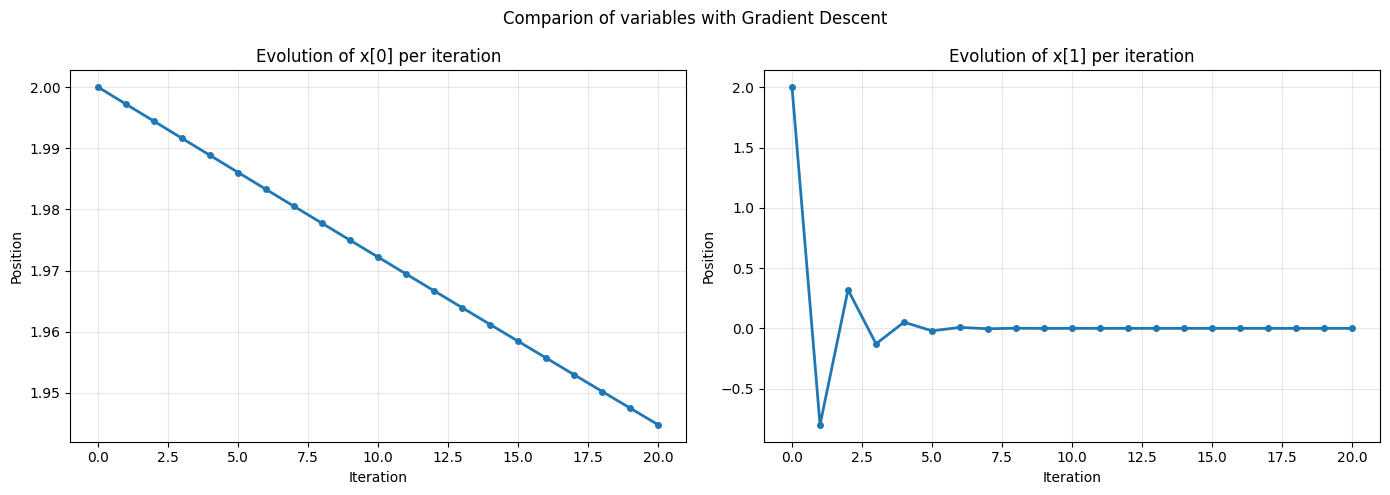

In [14]:
# We see here that learning rate is adapted to x[1], so x[0] goes towards the 
# minimum very slowly, while x[1] gets there really fast
positions1, losses1 = gradient_descent(0.0007, 
                                     num_iterations=20, 
                                     x_start=[2.0, 2.0], 
                                     gradient=multi_gradient, 
                                     loss_function=multi_function)
positions1 = np.array(positions1)

pos_x = positions1[:,0]
pos_y = positions1[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle("Comparion of variables with Gradient Descent")

axes[0].plot(pos_x, 'o-', linewidth=2, markersize=4)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Position')
axes[0].set_title('Evolution of x[0] per iteration')
axes[0].grid(True, alpha=0.3)

axes[1].plot(pos_y, 'o-', linewidth=2, markersize=4)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Position')
axes[1].set_title('Evolution of x[1] per iteration')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 4. Small noise can cause problems 

In [15]:
def noise_function(x):
    return 0.5 * x**2 + 0.1 * np.sin(100*x)

def noise_gradient(x):
    return x + 10 * np.cos(100*x)

In [16]:
# If the learning rate is higher than 1/(maximum of gradient), 
# we don't necessarily converge, even in a convex function.
interactive_optimizer_plot(
    optimizer=gradient_descent,
    gradient=noise_gradient,
    loss_function=noise_function,
    x_range=(-5, 5),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.5,
        "num_iterations": 10,
        "x_start": 2
    },
    title="Gradient Descent"
)
# Put 

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

### AdaGrad

AdaGrad improves on regular gradient descent by having an adaptive learning rate, which leads to large steps for a low gradient (exploration), and small steps for a large gradient (exploitation). For this, you introduce $v_t$, which is the cumulative sum of all previous gradients squared.
$$\begin{align*}
    v_0 &= 0\\
    v_t &= v_{t-1} + g_t^2\\[2pt]
    w_{t+1} &= w_t - \frac{\eta}{\sqrt{v_t}+\epsilon} \cdot g_t
\end{align*}$$
where $\epsilon$ is a small value to avoid division by 0.

In [17]:
def ada_grad(learning_rate, num_iterations=30, x_start=-2.0, gradient=gradient, loss_function=loss_function):
    eps = 1e-16
    x = np.array(x_start)
    losses = [loss_function(x)]
    positions = [x]
    vt = 0
    for _ in range(num_iterations):
        grad = np.array(gradient(x))
        vt += grad**2
        x = x - learning_rate * grad / (np.sqrt(vt) + eps)
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

In [18]:
interactive_optimizer_plot(
    optimizer=ada_grad,
    gradient=gradient_for_test_hyperparameters,
    loss_function=loss_function_for_test_hyperparameters,
    x_range=(-3, 4),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.2,
        "num_iterations": 40,
        "x_start": 4.0
    },
    title="AdaGrad"
)

interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

As $v_t$ is calculated per variable, we get better adaption of the learning rate in multidimensional spaces.

In [19]:
def multi_function(x):
    return x[0]**2 + 1000*x[1]**2

def multi_gradient(x):
    return np.array([2*x[0], 2000*x[1]])

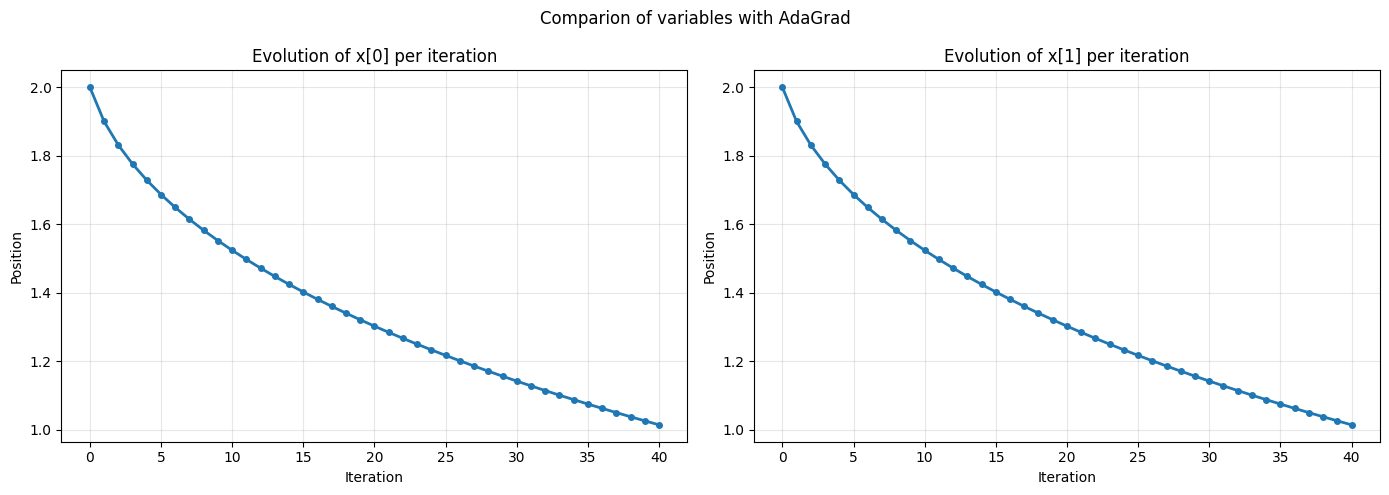

In [20]:
# We see here that the learning rate can be set a lot higher, and actually works the same 
# for x[0] md x[1]
# But we also see the slowing-down effect of AdaGrad
positions1, losses1 = ada_grad(0.1, 
                                     num_iterations=40, 
                                     x_start=[2.0, 2.0], 
                                     gradient=multi_gradient, 
                                     loss_function=multi_function)
positions1 = np.array(positions1)

pos_x = positions1[:,0]
pos_y = positions1[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparion of variables with AdaGrad")

axes[0].plot(pos_x, 'o-', linewidth=2, markersize=4)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Position')
axes[0].set_title('Evolution of x[0] per iteration')
axes[0].grid(True, alpha=0.3)

axes[1].plot(pos_y, 'o-', linewidth=2, markersize=4)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Position')
axes[1].set_title('Evolution of x[1] per iteration')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### RMSProp

In AdaGrad, $v_t$ is constantly growing. This can lead to a very small learning value, so the progress each round becomes minimal for high learning rates. RMSProp avoids this by using a moving average. For this, we introduce an additional parameter $\beta$, which defines the importance of the accumulated averages versus the current gradient.
$$\begin{align*}
    v_0 &= 0\\[2pt]
    v_t &= \beta v_{t-1} + (1-\beta) g_t^2\\[5pt]
    \hat{v}_t &= \frac{v_t}{1-\beta^t}\\
    w_{t+1} &= w_t - \frac{\eta}{\sqrt{\hat{v}_t}+\epsilon} \cdot g_t
\end{align*}$$
$\hat{v}_t$ is used to offset the bias created by the initial choice $v_0 = 0$.

In [21]:
def RMSProp(learning_rate, num_iterations=30, x_start=-2.0, beta=0.5, gradient=gradient, loss_function=loss_function):
    eps = 1e-16
    x = np.array(x_start)
    losses = [loss_function(x)]
    positions = [x]
    vt = 0
    for t in range(1, num_iterations + 1):
        grad = np.array(gradient(x))
        vt = beta * vt + (1-beta) * grad**2
        vt_bias = vt / (1-beta**t)
        x = x - learning_rate * grad / (np.sqrt(vt_bias) + eps)
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

In [22]:
interactive_optimizer_plot(
    optimizer=RMSProp,
    gradient=gradient_for_test_hyperparameters,
    loss_function=loss_function_for_test_hyperparameters,
    x_range=(-3, 4),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.2,
        "num_iterations": 40,
        "x_start": 4.0,
        "beta": 0.9
    },
    title="RMSProp"
)

interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

The smoothing helps with noise in functions.

In [23]:
def noise_function(x):
    return 0.5 * x**2 + 0.1 * np.sin(100*x)

def noise_gradient(x):
    return x + 10 * np.cos(100*x)

In [24]:
interactive_optimizer_plot(
    optimizer=RMSProp,
    gradient=noise_gradient,
    loss_function=noise_function,
    x_range=(-3, 4),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.5,
        "num_iterations": 40,
        "x_start": 4.0,
        "beta": 0.7
    },
    title="RMSProp"
)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

For multi-variable functions, we also get a cleaner descent:

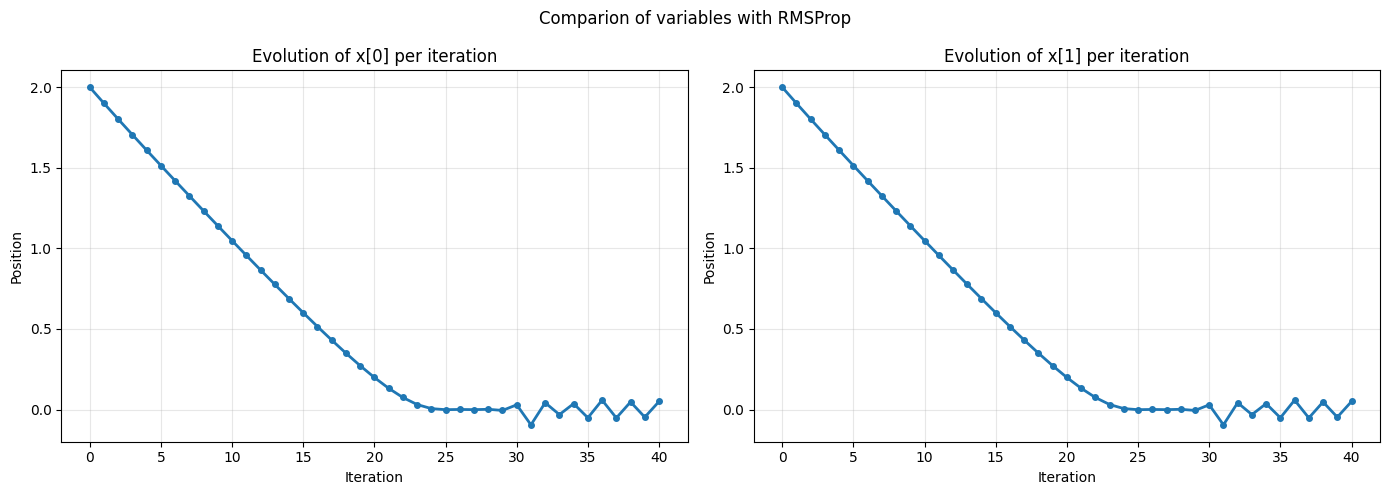

In [25]:
# We see here that the learning rate can be set a lot higher, and actually works the same 
# for x[0] md x[1]
positions1, losses1 = RMSProp(0.1, 
                                     num_iterations=40, 
                                     x_start=[2.0, 2.0], 
                                     gradient=multi_gradient, 
                                     loss_function=multi_function)
positions1 = np.array(positions1)

pos_x = positions1[:,0]
pos_y = positions1[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparion of variables with RMSProp")

axes[0].plot(pos_x, 'o-', linewidth=2, markersize=4)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Position')
axes[0].set_title('Evolution of x[0] per iteration')
axes[0].grid(True, alpha=0.3)

axes[1].plot(pos_y, 'o-', linewidth=2, markersize=4)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Position')
axes[1].set_title('Evolution of x[1] per iteration')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Momentum

Momentum takes a different approach from the previous versions by adding *momentum*. If we keep moving downhill in one direct, we "speed up" and take bigger steps. If we then hit a spot that descends in the opposite direction, we decelarate. In this case, the step size decreases, but the direction only changes if the slope of the point we hit is large enough.
$$\begin{align*}
    m_0 &= 0\\[2pt]
    m_t &= \beta m_{t-1} + (1-\beta) g_t\\[5pt]
    \hat{m}_t &= \frac{m_t}{1-\beta^t}\\
    w_{t+1} &= w_t - \eta\cdot\hat{m}_t
\end{align*}$$
$\hat{m}_t$ is used to offset the bias created by the initial choice $m_0 = 0$.\
Note that the gradient is now no longer squared, so $m_t$ can be negative.

In [26]:
def momentum(learning_rate, num_iterations=30, x_start=-2.0, beta=0.5,  gradient=gradient, loss_function=loss_function):
    x = np.array(x_start)
    losses = [loss_function(x)]
    positions = [x]
    mt = 0
    for t in range(1, num_iterations + 1):
        grad = np.array(gradient(x))
        mt = beta * mt + (1-beta) * grad
        mt_bias = mt / (1-beta**t)
        x = x - learning_rate * mt_bias
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

In [27]:
def f_squared(x):
    return x**2

def grad_squared(x):
    return 2*x

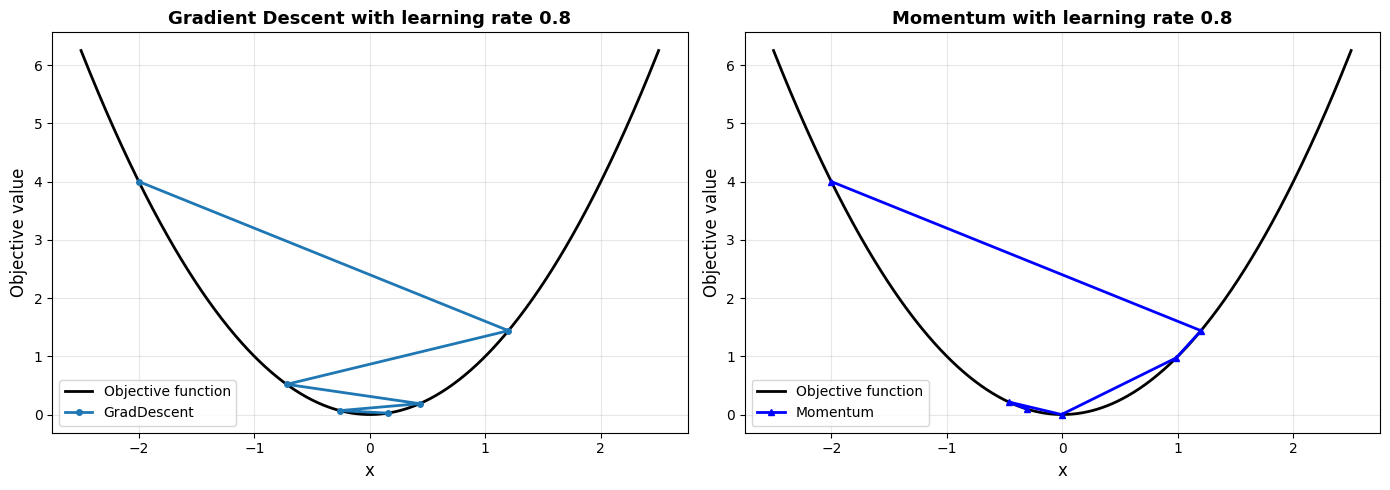

In [28]:
# Learning rates
learning_rate = 0.8

positions_gd, losses_gd = gradient_descent(learning_rate, loss_function=f_squared, gradient=grad_squared, x_start=-2, num_iterations=5)
positions_momentum, losses_momentum = momentum(learning_rate, loss_function=f_squared, gradient=grad_squared, x_start=-2, num_iterations=5)


# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Gradient Descent
x_range = np.linspace(-2.5, 2.5, 600)
y_range = f_squared(x_range)
axes[0].plot(x_range, y_range, 'k-', linewidth=2, label='Objective function')
axes[0].plot(positions_gd, losses_gd, 'o-', label=f'GradDescent', linewidth=2, markersize=4)


axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('Objective value', fontsize=12)
axes[0].set_title('Gradient Descent with learning rate 0.8', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Momentum
x_range = np.linspace(-2.5, 2.5, 600)
y_range = f_squared(x_range)
axes[1].plot(x_range, y_range, 'k-', linewidth=2, label='Objective function')
axes[1].plot(positions_momentum, losses_momentum, '^-', label=f'Momentum', linewidth=2, markersize=4, color='blue')


axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Objective value', fontsize=12)
axes[1].set_title('Momentum with learning rate 0.8', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
interactive_optimizer_plot(
    optimizer=momentum,
    gradient=gradient_for_test_hyperparameters,
    loss_function=loss_function_for_test_hyperparameters,
    x_range=(-3, 4),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.22,
        "num_iterations": 10,
        "x_start": 4.0,
        "beta": 0.9
    },
    title="Momentum"
)

interactive(children=(FloatSlider(value=0.22, continuous_update=False, description='learning_rate', max=2.0, m…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

Momentum helps solve the issue of small noise.

In [30]:
interactive_optimizer_plot(
    optimizer=momentum,
    gradient=noise_gradient,
    loss_function=noise_function,
    x_range=(-5, 5),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.2,
        "num_iterations": 15,
        "x_start": 3,
        "beta": 0.7
    },
    title="Momentum"
)

interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

### Adam

Adam combines RMSProp and Momentum to get smooth gradient direction (from Momentum) and adaptive scaling (from RMSProp).
$$\begin{align*}
    m_0 &= 0\qquad\qquad v_0 = 0\\[2pt]
    m_t &= \beta_1 \cdot m_{t-1} + (1-\beta_1) \cdot g_t\;, \qquad \hat{m}_t = \frac{m_t}{1-\beta_1^t}\\[10pt]
    v_t &= \beta_2 v_{t-1} + (1-\beta_2) g_t^2\;, \qquad \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}\\
    w_{t+1} &= w_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
\end{align*}$$

In [31]:
def adam(learning_rate, num_iterations=30, x_start=-2.0, beta1=0.5, beta2=0.5, gradient=gradient, loss_function=loss_function):
    eps = 1e-16
    x = np.array(x_start)
    losses = [loss_function(x)]
    positions = [x]
    mt = 0
    vt = 0
    for t in range(1, num_iterations + 1):
        grad = np.array(gradient(x))

        mt = beta1 * mt + (1-beta1) * grad
        mt_bias = mt / (1-beta1**t)

        vt = beta2 * vt + (1-beta2) * grad**2
        vt_bias = vt / (1-beta2**t)

        x = x  - learning_rate * mt_bias / (np.sqrt(vt_bias) + eps)
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

In [32]:
interactive_optimizer_plot(
    optimizer=adam,
    gradient=gradient_for_test_hyperparameters,
    loss_function=loss_function_for_test_hyperparameters,
    x_range=(-3, 3),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.3,
        "num_iterations": 15,
        "x_start": 2.0,
        "beta1": 0.7,
        "beta2": 0.7
    },
    title="Adam"
)

interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

### Test Comparison (Draft)

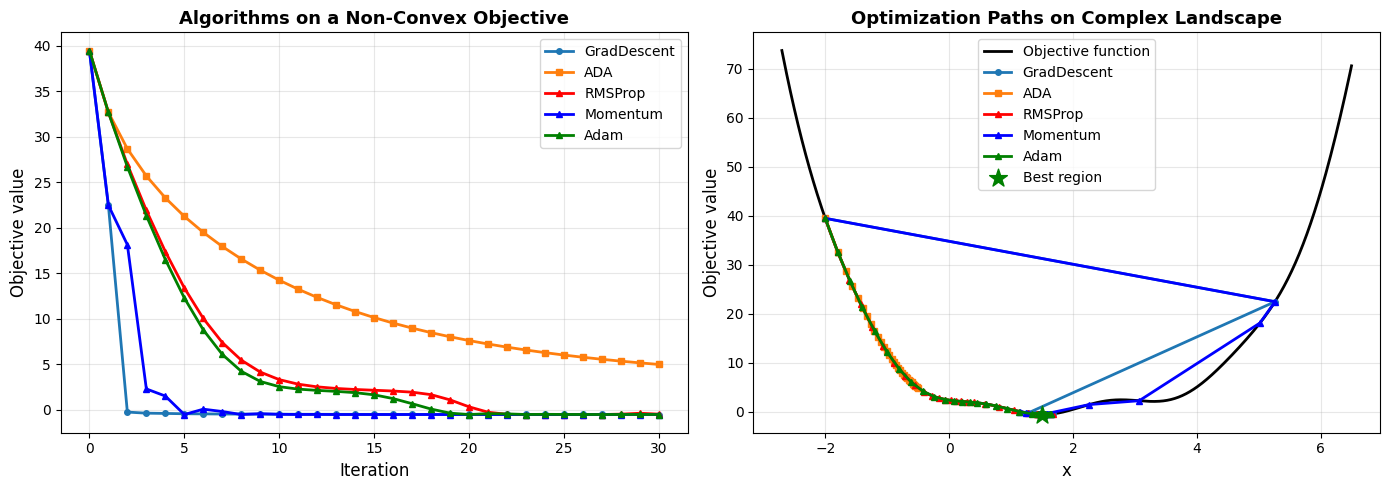

In [33]:
# Learning rates
learning_rate = 0.2

positions_gd, losses_gd = gradient_descent(learning_rate)
positions_ada, losses_ada = ada_grad(learning_rate)
positions_rmsp, losses_rsmp = RMSProp(learning_rate)
positions_momentum, losses_momentum = momentum(learning_rate)
positions_adam, losses_adam = adam(learning_rate)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Objective value over iterations
iterations = range(len(losses_gd))
axes[0].plot(iterations, losses_gd, 'o-', label=f'GradDescent', linewidth=2, markersize=4)
axes[0].plot(iterations, losses_ada, 's-', label=f'ADA', linewidth=2, markersize=4)
axes[0].plot(iterations, losses_rsmp, '^-', label=f'RMSProp', linewidth=2, markersize=4, color='red')
axes[0].plot(iterations, losses_momentum, '^-', label=f'Momentum', linewidth=2, markersize=4, color='blue')
axes[0].plot(iterations, losses_adam, '^-', label=f'Adam', linewidth=2, markersize=4, color='green')


axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Objective value', fontsize=12)
axes[0].set_title('Algorithms on a Non-Convex Objective', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# Plot 2: Optimization paths on the landscape
x_range = np.linspace(-2.7, 6.5, 600)
y_range = loss_function(x_range)
axes[1].plot(x_range, y_range, 'k-', linewidth=2, label='Objective function')
axes[1].plot(positions_gd, losses_gd, 'o-', label=f'GradDescent', linewidth=2, markersize=4)
axes[1].plot(positions_ada, losses_ada, 's-', label=f'ADA', linewidth=2, markersize=4)
axes[1].plot(positions_rmsp, losses_rsmp, '^-', label=f'RMSProp', linewidth=2, markersize=4, color='red')
axes[1].plot(positions_momentum, losses_momentum, '^-', label=f'Momentum', linewidth=2, markersize=4, color='blue')
axes[1].plot(positions_adam, losses_adam, '^-', label=f'Adam', linewidth=2, markersize=4, color='green')

best_idx = np.argmin(y_range) # Mark an optimal value
axes[1].scatter([x_range[best_idx]], [y_range[best_idx]], color='green', s=180, marker='*', label='Best region', zorder=5)

axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Objective value', fontsize=12)
axes[1].set_title('Optimization Paths on Complex Landscape', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()